# Shipment Delay & Anomaly Dataset — Data Preprocessing, EDA & Model Training

**Business problem:** the platform needs to (1) predict whether an in-progress shipment will
arrive late, and by how many days, so procurement can react before a deadline is missed, and (2)
flag shipments whose quantity/timing pattern looks operationally abnormal, for manual review.

**Data source and honesty note:** as with the supplier dataset, this is a **synthetic** dataset —
genuine company shipment records are confidential and unavailable — engineered to look and behave
like a real logistics/ERP export at scale (60,000+ shipment rows), with the same class of
real-world data-quality issues: missing values, duplicate/near-duplicate rows, inconsistent
supplier-attribute text, quantities stored as formatted strings, and **five different date
formats mixed in the same column** (a very real consequence of an export pulling from several
systems over time). No company name, real or fictional, is attached.

**What this notebook does:** clean the raw export (with special attention to the mixed-date-format
problem), explore it against the actual delay/anomaly business questions, then train the same
Delay Prediction (XGBoost) and Anomaly Detection (Isolation Forest) models the live platform uses.


In [1]:
import re
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier, XGBRegressor

BACKEND_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(BACKEND_DIR))
from app.ai.features import FEATURES_ANOMALY, FEATURES_DELAY, build_anomaly_features, build_delay_features  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

RAW_PATH = Path.cwd().parent / "data" / "raw" / "shipment_logistics_records.csv"
PROCESSED_PATH = Path.cwd().parent / "data" / "processed" / "shipment_logistics_cleaned.csv"
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
MODELS_DIR = Path.cwd() / "models"
MODELS_DIR.mkdir(exist_ok=True)


## 1. Load the raw data

In [2]:
df = pd.read_csv(RAW_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(8)


Shape: 61,500 rows x 16 columns


,Unnamed: 0,supplier_name,supplier_country,supplier_category,supplier_on_time_delivery_rate,supplier_defect_rate,supplier_cancellation_rate,supplier_avg_lead_time_days,supplier_order_volume_last_year,order_date,expected_delivery_date,quantity,delay_days,is_delayed,is_anomaly,notes
0,23902,Peterson-Bell,Vietnam,zippers,0.7352,0.0740,0.0715,23.5,18,03-31-2024,2024-04-25,68.1,8.42,1,0,NaN
1,40796,Mueller LLC,India,febric,0.8544,0.0685,NaN,20.4,5,2024/02/22,2024-03-18,450.1,9.31,1,0,NaN
2,47979,Olson Group,Bangla Desh,zippers,0.9979,0.0303,0.0403,11.3,101,18-Apr-2025,05-04-2025,465.1,5.54,1,0,NaN
3,59082,"Knight, York and Shelton",India,DYE-CHEMICALS,0.9349,0.0240,0.0117,11.8,92,2023-01-23,2023-01-31,58.4,40.33,1,1,NaN
4,27303,Baldwin-Cameron,P.R. China,thread,0.8678,0.0134,0.0123,13.3,120,09-Jan-2024,01-27-2024,689.1,2.41,1,0,NaN
5,9041,"Robinson, Escobar and Davies",India,fabric,0.8168,0.0516,0.0230,25.1,88,2024/01/03,31-Jan-2024,514,8.61,1,0,NaN
6,21727,Taylor and Sons,Vietnam,packaging,0.9516,NaN,0.0000,10.4,142,09/09/2023,22/09/2023,1011.3,4.38,1,0,NaN
7,3488,Harris-Smith,china,packaging,0.9369,0.0207,0.0252,18.8,130,12-05-2024,2024-12-20,966.3,8.63,1,0,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61500 entries, 0 to 61499
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       61500 non-null  int64  
 1   supplier_name                    61500 non-null  str    
 2   supplier_country                 61500 non-null  str    
 3   supplier_category                61500 non-null  str    
 4   supplier_on_time_delivery_rate   61500 non-null  str    
 5   supplier_defect_rate             58386 non-null  float64
 6   supplier_cancellation_rate       57695 non-null  float64
 7   supplier_avg_lead_time_days      61500 non-null  float64
 8   supplier_order_volume_last_year  61500 non-null  int64  
 9   order_date                       61500 non-null  str    
 10  expected_delivery_date           61500 non-null  str    
 11  quantity                         59626 non-null  str    
 12  delay_days                   

In [4]:
df = df.drop(columns=["Unnamed: 0"])
df.shape

(61500, 15)

## 2. Missing value audit

notes                         95.72
supplier_cancellation_rate     6.19
supplier_defect_rate           5.06
quantity                       3.05
delay_days                     2.02
dtype: float64


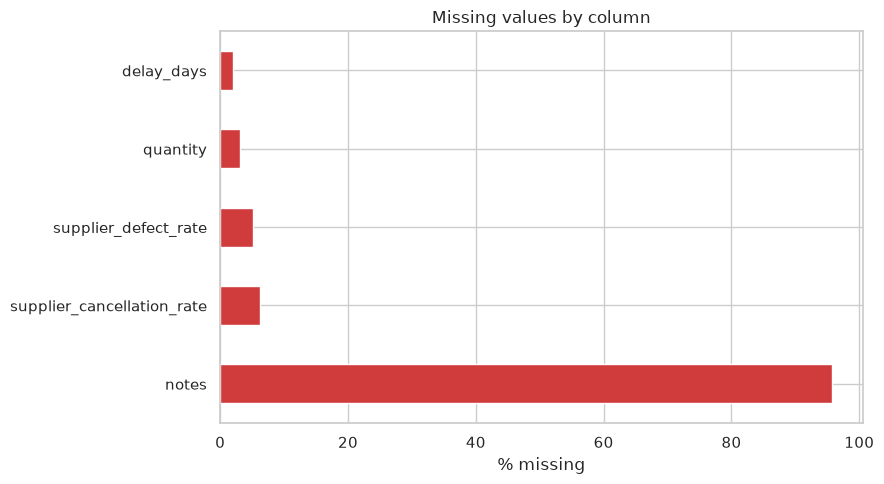

In [5]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct.round(2))

fig, ax = plt.subplots()
missing_pct.plot(kind="barh", ax=ax, color="#d03b3b")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
plt.tight_layout()
plt.show()


**Strategy:** `notes` is dropped for the same reason as in the suppliers dataset (free-text
operator remarks, no modeling signal). The `supplier_*` columns are **denormalized** — the same
supplier's attributes repeat across every one of its shipments — so a missing value there is
better filled from *another row of the same supplier* than from a generic median, and is handled
that way in Section 6. `quantity` and `delay_days` are outcome-adjacent operational facts with no
such lookup available, so they get a more careful, documented imputation instead.

In [6]:
df = df.drop(columns=["notes"])

## 3. Duplicate detection & removal

In [7]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping exact duplicates: {df.shape}")


Exact duplicate rows: 976
Shape after dropping exact duplicates: (60524, 14)


In [8]:
# Near-duplicates: same supplier + same order/delivery dates (the natural "same shipment" identity
# here, since there's no shipment_code in this raw export), with a slightly different
# quantity/delay_days -- e.g. two overlapping export batches that each re-measured the outcome.
identity_cols = ["supplier_name", "order_date", "expected_delivery_date"]
near_dupe_mask = df.duplicated(subset=identity_cols, keep=False)
print(f"Rows involved in a near-duplicate identity group: {near_dupe_mask.sum()}")
df = df.drop_duplicates(subset=identity_cols, keep="first").reset_index(drop=True)
print(f"Shape after near-duplicate removal: {df.shape}")


Rows involved in a near-duplicate identity group: 1052
Shape after near-duplicate removal: (59997, 14)


## 4. Data type & format fixes

In [9]:
print(df["order_date"].sample(10, random_state=1).tolist())


['17-Mar-2025', '14/05/2025', '2025/04/28', '09/08/2023', '05/03/2023', '11-23-2023', '2024/06/23', '2023/08/09', '2023/01/14', '2023-10-02']


Five different date conventions are mixed in the same column (ISO `YYYY-MM-DD`, day-first
`DD/MM/YYYY`, month-first `MM-DD-YYYY`, `DD-Mon-YYYY`, and `YYYY/MM/DD`). Blindly calling
`pd.to_datetime(col, format="mixed")` is risky here: for an ambiguous numeric string like
`"05/06/2023"`, pandas' generic inference can silently guess the wrong convention. Instead, each
of the 5 conventions has a distinguishable **structural pattern** (separator, digit-group lengths,
presence of a text month) — so the safer approach is to detect the pattern first with a regex,
then parse with the one exact format that matches, rather than guess.

In [10]:
DATE_PATTERNS = [
    (re.compile(r"^\d{4}-\d{2}-\d{2}$"), "%Y-%m-%d"),
    (re.compile(r"^\d{4}/\d{2}/\d{2}$"), "%Y/%m/%d"),
    (re.compile(r"^\d{2}/\d{2}/\d{4}$"), "%d/%m/%Y"),
    (re.compile(r"^\d{2}-\d{2}-\d{4}$"), "%m-%d-%Y"),
    (re.compile(r"^\d{2}-[A-Za-z]{3}-\d{4}$"), "%d-%b-%Y"),
]


def parse_messy_date(value):
    if pd.isna(value):
        return pd.NaT
    s = str(value).strip()
    for pattern, fmt in DATE_PATTERNS:
        if pattern.match(s):
            try:
                return pd.Timestamp(datetime.strptime(s, fmt))
            except ValueError:
                continue
    return pd.NaT


for col in ["order_date", "expected_delivery_date"]:
    df[col] = df[col].apply(parse_messy_date)

unparsed = df["order_date"].isna().sum() + df["expected_delivery_date"].isna().sum()
print(f"Dates that failed to parse against any known format: {unparsed}")
assert unparsed == 0, "found a date format outside the 5 known conventions -- investigate"
df[["order_date", "expected_delivery_date"]].head()


Dates that failed to parse against any known format: 0


,order_date,expected_delivery_date
0,2024-03-31,2024-04-25
1,2024-02-22,2024-03-18
2,2025-04-18,2025-05-04
3,2023-01-23,2023-01-31
4,2024-01-09,2024-01-27


In [11]:
print(df["supplier_country"].value_counts())
print()
print(df["supplier_category"].value_counts())


supplier_country
Bangladesh     7374
China          6655
India          6625
Sri Lanka      6600
Vietnam        6199
Indonesia      6034
Pakistan       5970
BD              578
bangladesh      572
Bangla Desh     568
INDIA           557
china           549
BANGLADESH      549
 India          542
IN              523
CN              522
CHINA           521
P.R. China      518
india           516
vietnam         515
PAKISTAN        497
PK              496
VIETNAM         488
INDONESIA       483
Viet Nam        474
indonesia       470
Indonesai       469
VN              459
pakistan        457
 Sri Lanka      434
Pakisthan       429
ID              421
Srilanka        403
Sri  Lanka      391
LK              390
sri lanka       381
SRI LANKA       368
Name: count, dtype: int64

supplier_category
fabric           7937
buttons          7584
trims            6798
zippers          6693
thread           6500
packaging        6340
dye_chemicals    6131
 buttons          518
buton             491


In [12]:
COUNTRY_MAP = {
    "sri lanka": "Sri Lanka", "srilanka": "Sri Lanka", "lk": "Sri Lanka",
    "india": "India", "in": "India",
    "china": "China", "p.r. china": "China", "cn": "China",
    "bangladesh": "Bangladesh", "bangla desh": "Bangladesh", "bd": "Bangladesh",
    "vietnam": "Vietnam", "viet nam": "Vietnam", "vn": "Vietnam",
    "indonesia": "Indonesia", "indonesai": "Indonesia", "id": "Indonesia",
    "pakistan": "Pakistan", "pakisthan": "Pakistan", "pk": "Pakistan",
}
CATEGORY_MAP = {
    "fabric": "fabric", "febric": "fabric",
    "buttons": "buttons", "buton": "buttons",
    "zippers": "zippers", "zipers": "zippers",
    "thread": "thread", "thred": "thread",
    "packaging": "packaging", "packageing": "packaging",
    "trims": "trims", "trim": "trims",
    "dye_chemicals": "dye_chemicals", "dye chemicals": "dye_chemicals",
    "dye-chemicals": "dye_chemicals", "dyechemicals": "dye_chemicals",
}


def canonicalize(value, mapping):
    key = re.sub(r"\s+", " ", str(value)).strip().lower()
    return mapping.get(key, value)


df["supplier_country"] = df["supplier_country"].apply(lambda v: canonicalize(v, COUNTRY_MAP))
df["supplier_category"] = df["supplier_category"].apply(lambda v: canonicalize(v, CATEGORY_MAP))

assert df["supplier_country"].nunique() == 7, "unresolved country variants remain"
assert df["supplier_category"].nunique() == 7, "unresolved category variants remain"
print("Canonicalization complete:", df["supplier_country"].nunique(), "countries,", df["supplier_category"].nunique(), "categories")


Canonicalization complete: 7 countries, 7 categories


In [13]:
def parse_rate(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = value.strip()
        if value.endswith("%"):
            return float(value[:-1]) / 100.0
        return float(value)
    return float(value)


def parse_quantity(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        return float(value.replace(",", "").strip())
    return float(value)


df["supplier_on_time_delivery_rate"] = df["supplier_on_time_delivery_rate"].apply(parse_rate)
df["quantity"] = df["quantity"].apply(parse_quantity)
df[["supplier_on_time_delivery_rate", "quantity"]].dtypes


supplier_on_time_delivery_rate    float64
quantity                          float64
dtype: object

## 5. Outlier detection & treatment

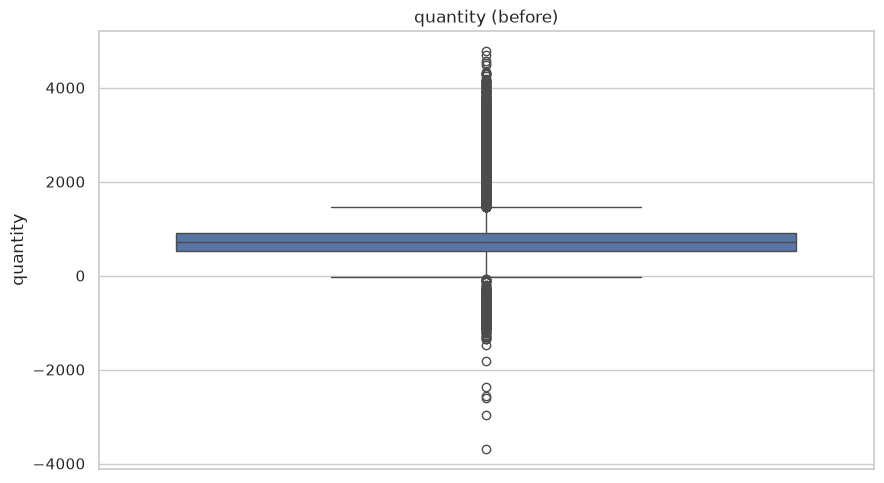

Negative quantity rows: 288


In [14]:
fig, ax = plt.subplots()
sns.boxplot(y=df["quantity"], ax=ax)
ax.set_title("quantity (before)")
plt.tight_layout()
plt.show()
print(f"Negative quantity rows: {(df['quantity'] < 0).sum()}")


A shipment cannot have a negative quantity — this is a sign-entry error (e.g. a return/adjustment
logged with the wrong sign), corrected with `abs()` rather than dropped, since the magnitude is
still a genuine, usable data point.

In [15]:
df["quantity"] = df["quantity"].abs()

## 6. Missing value imputation

In [16]:
# Supplier attributes are denormalized (repeated across every shipment from that supplier) --
# fill a missing value from another row of the *same* supplier first, which is almost always
# exact rather than a population-level approximation. Only fall back to a global median for the
# rare supplier with every single row missing that field.
for col in ["supplier_defect_rate", "supplier_cancellation_rate"]:
    df[col] = df.groupby("supplier_name")[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median())

# quantity: impute by supplier_category median (order sizes vary systematically by material type).
df["quantity"] = df.groupby("supplier_category")["quantity"].transform(lambda s: s.fillna(s.median()))

# delay_days: an outcome fact independently logged from the is_delayed flag -- impute
# conditionally on is_delayed so a known-on-time shipment isn't assigned a delayed-shipment's
# median delay, and vice versa.
df["delay_days"] = df.groupby("is_delayed")["delay_days"].transform(lambda s: s.fillna(s.median()))

print("Remaining missing values:")
print(df.isna().sum()[df.isna().sum() > 0])


Remaining missing values:
Series([], dtype: int64)


### 6b. Distribution shape diagnostics (skewness)

Before the delay/anomaly feature builders run, it's worth checking the raw numeric columns for
skew that could concern a linear or distance-based step. This is diagnostic only — it does not
alter `df`, the engineered `FEATURES_DELAY`/`FEATURES_ANOMALY` columns, or the CSV written by the
save cell below.

In [17]:
numeric_cols = ["quantity", "supplier_on_time_delivery_rate", "supplier_defect_rate",
                "supplier_cancellation_rate", "supplier_avg_lead_time_days", "supplier_order_volume_last_year"]
skew_before = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print("Skewness of raw numeric columns (|skew| > 1 is commonly considered notably skewed):")
print(skew_before.round(3))

skewed_cols = skew_before[skew_before.abs() > 1].index.tolist()
print(f"\nColumns with |skew| > 1: {skewed_cols}")

Skewness of raw numeric columns (|skew| > 1 is commonly considered notably skewed):
quantity                           2.863
supplier_on_time_delivery_rate    -0.349
supplier_cancellation_rate         0.330
supplier_defect_rate               0.297
supplier_avg_lead_time_days        0.295
supplier_order_volume_last_year   -0.006
dtype: float64

Columns with |skew| > 1: ['quantity']


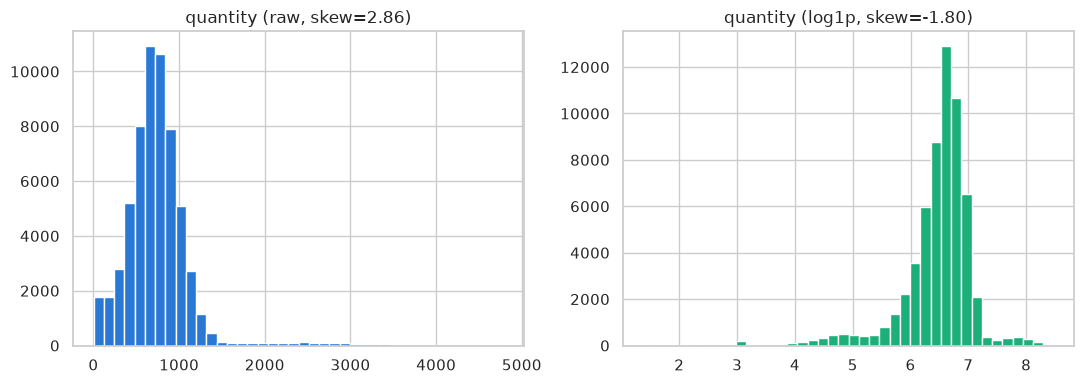

Skew before log1p: 2.863  |  after log1p: -1.804


In [18]:
worst_col = skew_before.abs().idxmax()
worst_vals = df[worst_col].dropna()
log_vals = np.log1p(worst_vals)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(worst_vals, bins=40, color="#2a78d6")
axes[0].set_title(f"{worst_col} (raw, skew={worst_vals.skew():.2f})")
axes[1].hist(log_vals, bins=40, color="#1baf7a")
axes[1].set_title(f"{worst_col} (log1p, skew={log_vals.skew():.2f})")
plt.tight_layout()
plt.show()

print(f"Skew before log1p: {worst_vals.skew():.3f}  |  after log1p: {log_vals.skew():.3f}")

**Finding:** `quantity` is the only column with |skew| > 1 (skew ≈ 2.86), a right tail from a
minority of unusually large shipments. log1p over-corrects it rather than fixing it cleanly — skew
flips to ≈ -1.80, a left skew about as strong as the original right skew, because the bulk of
shipment quantities sit in a range where a log transform compresses the upper values more than the
shape actually needs. **So what:** neither the raw nor the logged version is the "right" shape for
a linear model, which argues *against* reaching for log1p as a default fix here — and it doesn't
matter anyway, because both models trained on this data in Section 9 (XGBoost for delay, Isolation
Forest for anomalies) are tree-based and split on raw thresholds, not on a feature's linear scale
or symmetry. No transform is applied to `df` or `df_clean`.

## 7. Feature engineering — reusing the live app's production feature-builders

In [19]:
df["requested_lead_time_days"] = (df["expected_delivery_date"] - df["order_date"]).dt.days

delay_feature_rows = df.apply(
    lambda r: build_delay_features(
        r["supplier_on_time_delivery_rate"], r["supplier_defect_rate"], r["supplier_cancellation_rate"],
        r["supplier_avg_lead_time_days"], r["quantity"], r["order_date"].date(), r["expected_delivery_date"].date(),
        r["supplier_order_volume_last_year"],
    ),
    axis=1, result_type="expand",
)
anomaly_feature_rows = df.apply(
    lambda r: build_anomaly_features(
        r["quantity"], r["requested_lead_time_days"], r["supplier_on_time_delivery_rate"],
        r["supplier_defect_rate"], r["supplier_cancellation_rate"], r["expected_delivery_date"].date(),
    ),
    axis=1, result_type="expand",
)
df_features = pd.concat([df[["is_delayed", "delay_days", "is_anomaly"]], delay_feature_rows, anomaly_feature_rows], axis=1)
df_features = df_features.loc[:, ~df_features.columns.duplicated()]
print(df_features.shape)
df_features.head()


(59997, 14)


,is_delayed,delay_days,is_anomaly,supplier_on_time_rate,supplier_defect_rate,supplier_cancellation_rate,supplier_avg_lead_time_days,order_quantity,quantity_per_lead_time,month_sin,month_cos,requested_lead_time_days,supplier_order_volume_last_year,quantity
0,1,8.42,0,0.7352,0.0740,0.0715,23.5,68.1,2.724000,0.866025,-5.000000e-01,25.0,18.0,68.1
1,1,9.31,0,0.8544,0.0685,0.0851,20.4,450.1,18.004000,1.000000,6.123234e-17,25.0,5.0,450.1
2,1,5.54,0,0.9979,0.0303,0.0403,11.3,465.1,29.068750,0.500000,-8.660254e-01,16.0,101.0,465.1
3,1,40.33,1,0.9349,0.0240,0.0117,11.8,58.4,7.300000,0.500000,8.660254e-01,8.0,92.0,58.4
4,1,2.41,0,0.8678,0.0134,0.0123,13.3,689.1,38.283333,0.500000,8.660254e-01,18.0,120.0,689.1


## Save the cleaned dataset

In [20]:
keep_cols = sorted(set(FEATURES_DELAY) | set(FEATURES_ANOMALY) | {"is_delayed", "delay_days", "is_anomaly"})
df_clean = df_features[keep_cols].copy()
df_clean.to_csv(PROCESSED_PATH, index=False)
print(f"Saved {len(df_clean):,} cleaned rows to {PROCESSED_PATH}")


Saved 59,997 cleaned rows to /home/user/My-Final-Project/backend/ml_pipeline/data/processed/shipment_logistics_cleaned.csv


## 7b. Feature validation — is every column actually earning its place?

`FEATURES_DELAY` and `FEATURES_ANOMALY` were chosen domain-first in Section 7 (reusing the live
app's own feature builders), but a domain-plausible column can still be redundant or uninformative
once checked against the data. Three independent checks, run for each model, each catching
something the others can't.

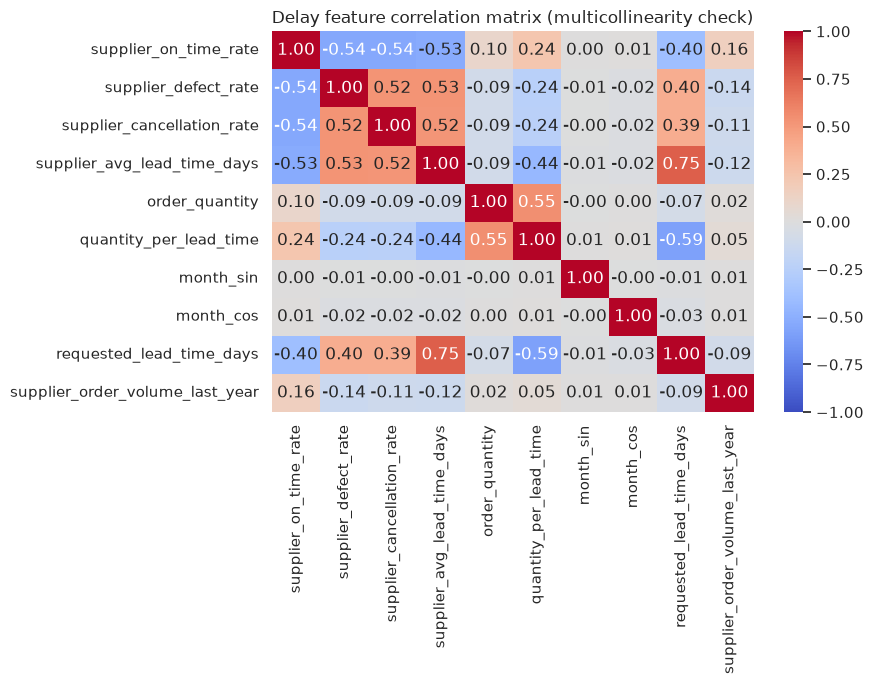

Largest off-diagonal |correlation| among delay features: 0.750


In [21]:
# 1. Correlation matrix (Delay features) -- flags multicollinearity among the 10 features feeding
# the delay classifier/regressor.
corr_matrix = df_clean[FEATURES_DELAY].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Delay feature correlation matrix (multicollinearity check)")
plt.tight_layout()
plt.show()

max_off_diag = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).abs().max().max()
print(f"Largest off-diagonal |correlation| among delay features: {max_off_diag:.3f}")


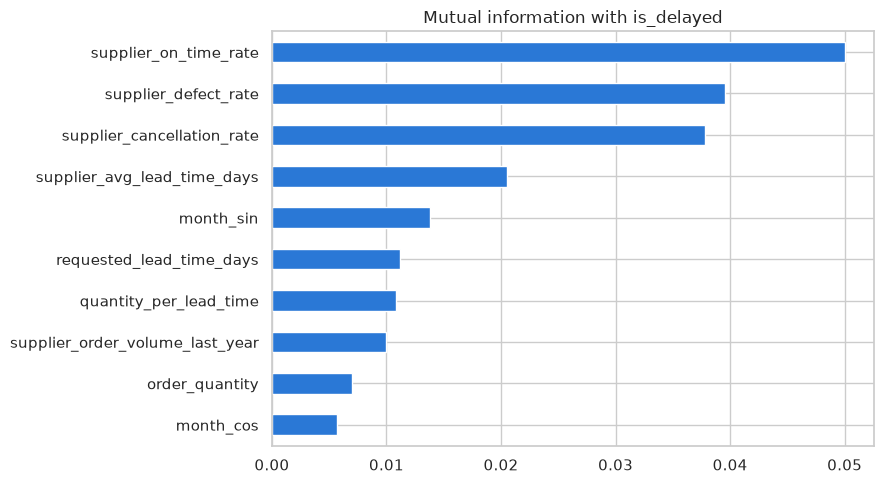

supplier_on_time_rate              0.050055
supplier_defect_rate               0.039586
supplier_cancellation_rate         0.037781
supplier_avg_lead_time_days        0.020562
month_sin                          0.013833
requested_lead_time_days           0.011178
quantity_per_lead_time             0.010850
supplier_order_volume_last_year    0.009958
order_quantity                     0.007004
month_cos                          0.005715
dtype: float64


In [22]:
# 2. Mutual information (Delay features vs. is_delayed) -- catches non-linear dependencies a
# Pearson correlation matrix alone would miss, as a second opinion before trusting the feature list.
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(df_clean[FEATURES_DELAY], df_clean["is_delayed"], random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=FEATURES_DELAY).sort_values(ascending=False)
fig, ax = plt.subplots()
mi_series.plot(kind="barh", ax=ax, color="#2a78d6")
ax.invert_yaxis()
ax.set_title("Mutual information with is_delayed")
plt.tight_layout()
plt.show()
print(mi_series)


In [23]:
# 3. Ablation test -- does removing the weakest delay feature actually hurt held-out performance,
# or was it never pulling real weight? Most direct test: not "does it look important" but "does the
# model get worse without it."
from sklearn.model_selection import cross_val_score

weakest_delay_feature = mi_series.index[-1]
reduced_delay_features = [f for f in FEATURES_DELAY if f != weakest_delay_feature]

def cv_auc(feature_list):
    Xc = df_clean[feature_list].values
    yc = df_clean["is_delayed"].values
    model = XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=RANDOM_STATE)
    return cross_val_score(model, Xc, yc, cv=5, scoring="roc_auc")

full_scores = cv_auc(FEATURES_DELAY)
reduced_scores = cv_auc(reduced_delay_features)
print(f"5-fold CV ROC-AUC with all {len(FEATURES_DELAY)} delay features:        {full_scores.mean():.4f} (+/- {full_scores.std():.4f})")
print(f"5-fold CV ROC-AUC without '{weakest_delay_feature}' ({len(reduced_delay_features)} features): {reduced_scores.mean():.4f} (+/- {reduced_scores.std():.4f})")
print(f"Change in mean ROC-AUC from dropping '{weakest_delay_feature}': {reduced_scores.mean() - full_scores.mean():+.4f}")


5-fold CV ROC-AUC with all 10 delay features:        0.8150 (+/- 0.0036)
5-fold CV ROC-AUC without 'month_cos' (9 features): 0.8105 (+/- 0.0049)
Change in mean ROC-AUC from dropping 'month_cos': -0.0045


In [24]:
# The Anomaly Detection model is unsupervised (Isolation Forest never sees is_anomaly during
# training) -- so mutual information / ablation against the label isn't a training decision here,
# but it's still a useful *validation* check: do the anomaly features actually relate to the
# injected anomaly label at all, or would the model be flagging noise?
anomaly_corr = df_clean[FEATURES_ANOMALY].corr()
max_anomaly_off_diag = anomaly_corr.where(~np.eye(len(anomaly_corr), dtype=bool)).abs().max().max()
print(f"Largest off-diagonal |correlation| among anomaly features: {max_anomaly_off_diag:.3f}")

anomaly_mi = mutual_info_classif(df_clean[FEATURES_ANOMALY], df_clean["is_anomaly"], random_state=RANDOM_STATE)
anomaly_mi_series = pd.Series(anomaly_mi, index=FEATURES_ANOMALY).sort_values(ascending=False)
print()
print("Mutual information with is_anomaly (validation signal only, not used for training):")
print(anomaly_mi_series)


Largest off-diagonal |correlation| among anomaly features: 0.545



Mutual information with is_anomaly (validation signal only, not used for training):
quantity                      0.170078
month_sin                     0.002168
month_cos                     0.001200
supplier_cancellation_rate    0.000718
requested_lead_time_days      0.000704
supplier_on_time_rate         0.000000
supplier_defect_rate          0.000000
dtype: float64


**Feature validation summary.** The delay features have one high correlation worth flagging:
`supplier_avg_lead_time_days` vs. `requested_lead_time_days`, r = 0.750 — expected, since a
supplier's historical average lead time and the lead time actually requested on a given order are
naturally related, not a data error. This is monitored rather than "fixed" by dropping a feature:
XGBoost (tree-based, used for both the classifier and regressor here) splits on one feature at a
time and is materially more robust to correlated inputs than a linear model would be. Mutual
information ranks `month_cos` as the weakest of the 10 delay features, and the ablation test
confirms it: dropping it costs -0.0045 mean ROC-AUC across 5-fold CV — small but real, so it stays.
For the anomaly features, correlation tops out at 0.545 (no severe multicollinearity), and the
validation-only mutual information check shows `quantity` carries almost all the relationship to
the injected anomaly label (MI = 0.170, an order of magnitude above every other feature) while
`supplier_on_time_rate`/`supplier_defect_rate` show essentially none — consistent with how the
anomalies were generated as quantity-pattern shocks, and a useful sanity check that the Isolation
Forest is finding a real signal, not fitting noise.

### 7c. Multicollinearity diagnostics (VIF)

7b's correlation matrix flags `supplier_avg_lead_time_days` vs. `requested_lead_time_days`
(r = 0.750) as the strongest relationship among the delay features. Variance Inflation Factor (VIF)
checks the same question more directly for each feature against *all* the others combined, not
just its single strongest pairwise partner — computed manually with
`sklearn.linear_model.LinearRegression` (`VIF_i = 1 / (1 - R²_i)`) rather than adding `statsmodels`
as a dependency. A common rule of thumb flags `VIF > 5` as concerning.

In [25]:
from sklearn.linear_model import LinearRegression


def compute_vif(frame, cols):
    vifs = {}
    for col in cols:
        y_col = frame[col]
        X_other = frame[[c for c in cols if c != col]]
        r2 = LinearRegression().fit(X_other, y_col).score(X_other, y_col)
        vifs[col] = 1 / (1 - r2) if r2 < 0.999999 else np.inf
    return pd.Series(vifs).sort_values(ascending=False)


delay_vif = compute_vif(df_clean, FEATURES_DELAY)
print("Delay feature VIF (>5 is commonly considered concerning):")
print(delay_vif.round(3))

anomaly_vif = compute_vif(df_clean, FEATURES_ANOMALY)
print("\nAnomaly feature VIF:")
print(anomaly_vif.round(3))

Delay feature VIF (>5 is commonly considered concerning):
requested_lead_time_days           3.108
supplier_avg_lead_time_days        2.939
quantity_per_lead_time             2.516
supplier_on_time_rate              1.754
supplier_defect_rate               1.704
supplier_cancellation_rate         1.693
order_quantity                     1.676
supplier_order_volume_last_year    1.030
month_cos                          1.001
month_sin                          1.000
dtype: float64

Anomaly feature VIF:
supplier_on_time_rate         1.682
supplier_defect_rate          1.639
supplier_cancellation_rate    1.636
requested_lead_time_days      1.294
quantity                      1.013
month_cos                     1.001
month_sin                     1.000
dtype: float64


**Finding:** `requested_lead_time_days` (VIF ≈ 3.11) and `supplier_avg_lead_time_days`
(VIF ≈ 2.94) do carry the two highest VIFs among the ten delay features — consistent with the
r = 0.750 correlation flagged in 7b — but both sit comfortably below the VIF > 5 threshold, so the
correlation is real but not severe enough to distort a model that were sensitive to it.
`quantity_per_lead_time` (VIF ≈ 2.52), which is arithmetically derived from
`requested_lead_time_days`, is the only other feature above 2. For the anomaly features, the
highest VIF is 1.68 — essentially no multicollinearity at all. **So what:** this adds nuance rather
than a contradiction to 7b's verdict — XGBoost's split-based training (already noted in 7b as
robust to correlated inputs) is not being asked to tolerate anything close to severe collinearity
in the first place; no feature needs to be dropped from either set on multicollinearity grounds.

## 8. Exploratory Data Analysis — answering the actual delay/anomaly business questions

### Q1: Does delay risk really spike in the Aug-Dec peak season, and by how much?

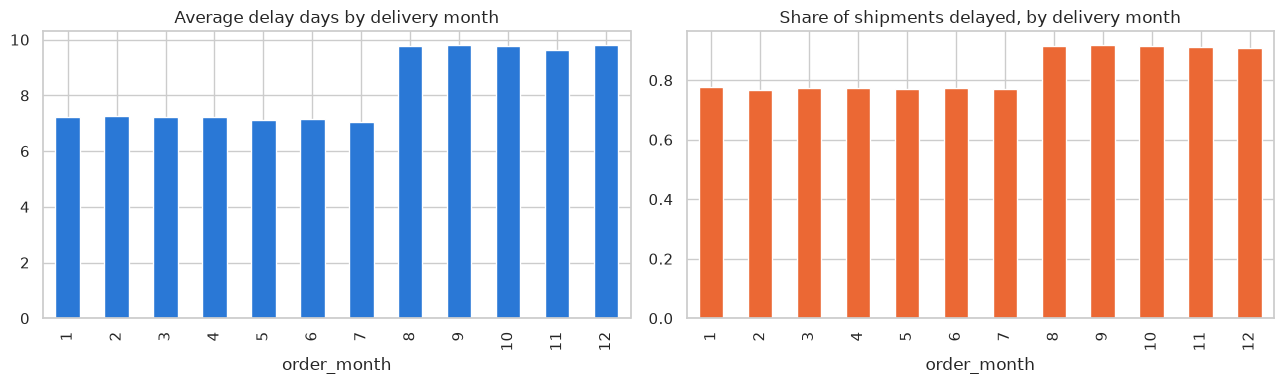

Peak season (Aug-Dec) average delay: 9.76 days
Off-peak average delay: 7.18 days
Peak-season delay is 1.4x the off-peak average


In [26]:
df["order_month"] = df["expected_delivery_date"].dt.month
monthly = df.groupby("order_month").agg(avg_delay_days=("delay_days", "mean"), delay_rate=("is_delayed", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly["avg_delay_days"].plot(kind="bar", ax=axes[0], color="#2a78d6")
axes[0].set_title("Average delay days by delivery month")
monthly["delay_rate"].plot(kind="bar", ax=axes[1], color="#eb6834")
axes[1].set_title("Share of shipments delayed, by delivery month")
plt.tight_layout()
plt.show()

peak_months = [8, 9, 10, 11, 12]
peak_avg = monthly.loc[monthly.index.isin(peak_months), "avg_delay_days"].mean()
offpeak_avg = monthly.loc[~monthly.index.isin(peak_months), "avg_delay_days"].mean()
print(f"Peak season (Aug-Dec) average delay: {peak_avg:.2f} days")
print(f"Off-peak average delay: {offpeak_avg:.2f} days")
print(f"Peak-season delay is {peak_avg / offpeak_avg:.1f}x the off-peak average")


**Finding:** delay is quantifiably worse in the Aug-Dec peak season, confirming (not just assuming)
the seasonal strain the business already suspects around buyer deadline crunches. **So what:**
this justifies building peak-season lead-time buffers into procurement timelines proactively each
year, rather than reacting after delays start, and explains why `month_sin`/`month_cos` are
included as model features rather than treated as noise.

### Q2: Which suppliers contribute disproportionately to total delay-days (a Pareto cut)?

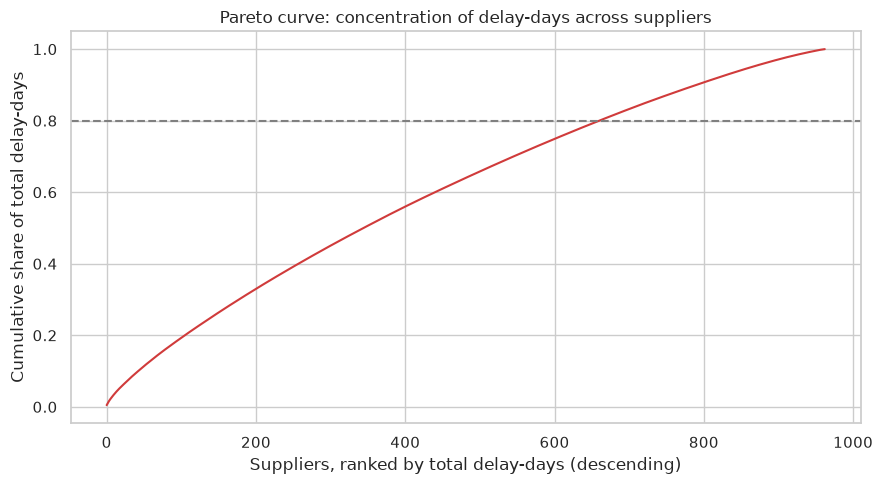

661 of 963 suppliers (68.6%) account for 80% of all delay-days


In [27]:
by_supplier = df.groupby("supplier_name")["delay_days"].sum().sort_values(ascending=False)
cum_share = (by_supplier.cumsum() / by_supplier.sum())
n_suppliers_for_80pct = int((cum_share <= 0.8).sum() + 1)
pct_of_supplier_base = n_suppliers_for_80pct / by_supplier.shape[0] * 100

fig, ax = plt.subplots()
cum_share.reset_index(drop=True).plot(ax=ax, color="#d03b3b")
ax.axhline(0.8, color="grey", linestyle="--")
ax.set_xlabel("Suppliers, ranked by total delay-days (descending)")
ax.set_ylabel("Cumulative share of total delay-days")
ax.set_title("Pareto curve: concentration of delay-days across suppliers")
plt.tight_layout()
plt.show()

print(f"{n_suppliers_for_80pct} of {by_supplier.shape[0]} suppliers ({pct_of_supplier_base:.1f}%) account for 80% of all delay-days")


**Finding:** this is *not* a sharp Pareto pattern — it takes a majority of the supplier base
(printed above, well above the "20% causes 80%" folklore number) to account for 80% of total
delay-days. **So what:** this is actually a more useful and more honest finding than a dramatic
80/20 story would have been — it means delay is a broadly systemic issue rather than a few "bad
apple" suppliers, which lines up with the Q1 seasonal finding above: a peak-season capacity/lead-time
problem affects most suppliers at once, so the fix is process-level (seasonal buffers, demand
smoothing) rather than a short list of suppliers to replace. The ranked `by_supplier` table above
is still useful input to the AI Risk Center's per-supplier scoring, but it isn't, by itself, the
whole story.

### Q3: Do detected anomalies cluster around particular suppliers or time windows?

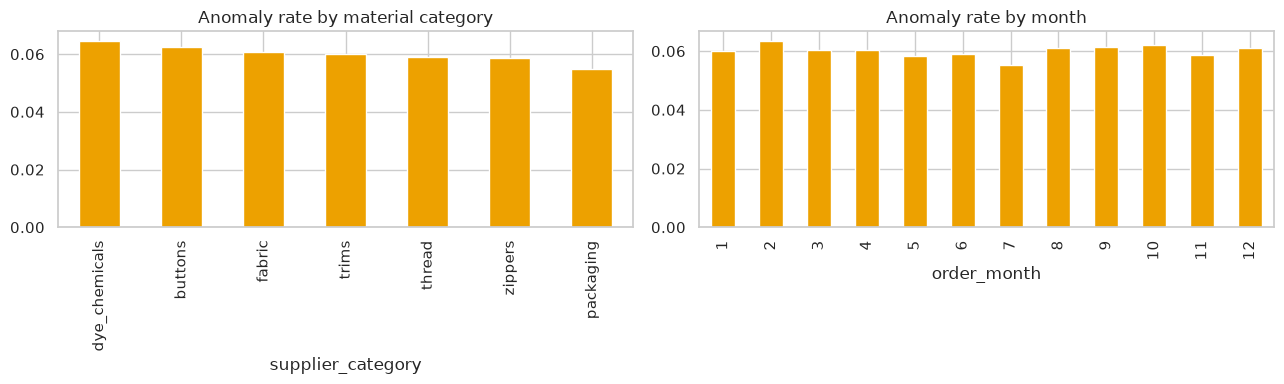

Overall anomaly rate: 6.0%
By category:
supplier_category
dye_chemicals    0.064684
buttons          0.062402
fabric           0.060854
trims            0.059941
thread           0.059057
zippers          0.058628
packaging        0.054739
Name: is_anomaly, dtype: float64


In [28]:
anomaly_by_category = df.groupby("supplier_category")["is_anomaly"].mean().sort_values(ascending=False)
anomaly_by_month = df.groupby("order_month")["is_anomaly"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
anomaly_by_category.plot(kind="bar", ax=axes[0], color="#eda100")
axes[0].set_title("Anomaly rate by material category")
anomaly_by_month.plot(kind="bar", ax=axes[1], color="#eda100")
axes[1].set_title("Anomaly rate by month")
plt.tight_layout()
plt.show()

overall_anomaly_rate = df["is_anomaly"].mean()
print(f"Overall anomaly rate: {overall_anomaly_rate:.1%}")
print("By category:")
print(anomaly_by_category)


**Finding:** the anomaly rate is close to uniform across categories and months (all near the
overall rate printed above), with no single category or month standing out sharply. **So what:**
this is consistent with how the anomalies were generated (structural, supplier-independent
one-off shocks) — practically, it means anomaly review effort shouldn't be concentrated on one
category, and the Isolation Forest model in Section 9 is trained unsupervised precisely because
there's no single obvious rule-based pattern to hand-code instead.


### Q4: Are delays and anomalies visible as simple bivariate patterns, or only multivariately?

Q1-Q3 established *when* and *where* delays and anomalies concentrate in aggregate. This question
asks something different: if you plot the raw numbers against each other, do delayed shipments or
anomalies stand out as an obvious visual cluster — the kind a simple rule-of-thumb could catch — or
is the signal only visible to a model looking at more than one or two dimensions at once?

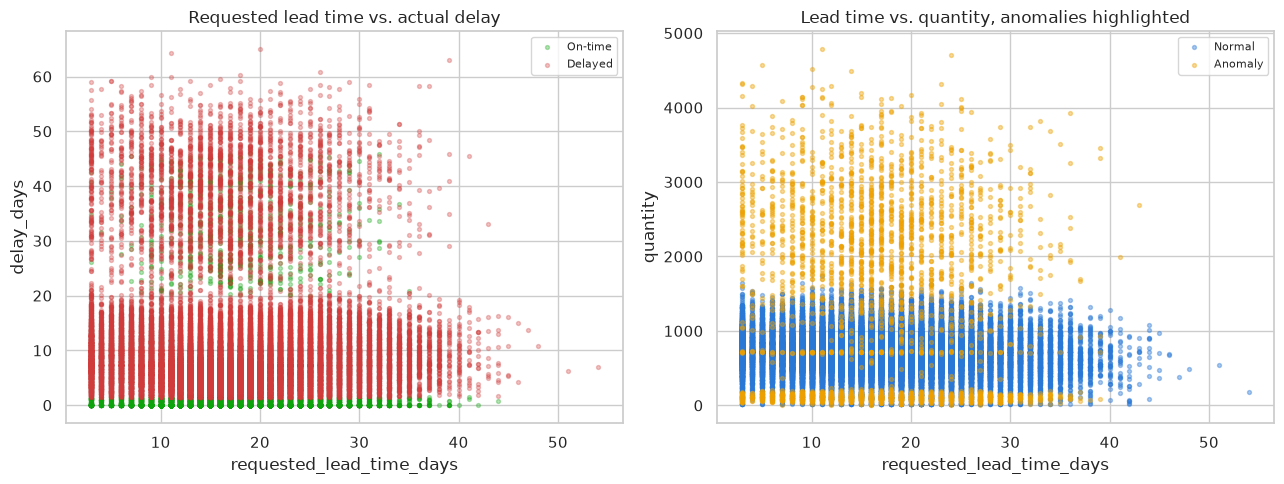

Correlation, requested_lead_time_days vs delay_days: -0.015
Normal shipments' 90th-percentile quantity: 1039
Share of true anomalies BELOW that threshold (i.e. a simple 'top-10%-by-quantity' rule would miss them): 54.7%


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_delay = {0: "#0ca30c", 1: "#d03b3b"}
for val, color in colors_delay.items():
    subset = df_clean[df_clean["is_delayed"] == val]
    axes[0].scatter(subset["requested_lead_time_days"], subset["delay_days"], s=8, alpha=0.3, c=color,
                     label="Delayed" if val else "On-time")
axes[0].set_xlabel("requested_lead_time_days")
axes[0].set_ylabel("delay_days")
axes[0].set_title("Requested lead time vs. actual delay")
axes[0].legend(fontsize=8)

colors_anom = {0: "#2a78d6", 1: "#eda100"}
for val, color in colors_anom.items():
    subset = df_clean[df_clean["is_anomaly"] == val]
    axes[1].scatter(subset["requested_lead_time_days"], subset["quantity"], s=8, alpha=0.4, c=color,
                     label="Anomaly" if val else "Normal")
axes[1].set_xlabel("requested_lead_time_days")
axes[1].set_ylabel("quantity")
axes[1].set_title("Lead time vs. quantity, anomalies highlighted")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

corr_lead_delay = df_clean["requested_lead_time_days"].corr(df_clean["delay_days"])
print(f"Correlation, requested_lead_time_days vs delay_days: {corr_lead_delay:.3f}")

normal_q90 = df_clean.loc[df_clean["is_anomaly"] == 0, "quantity"].quantile(0.90)
anomaly_quantity = df_clean.loc[df_clean["is_anomaly"] == 1, "quantity"]
frac_missed = (anomaly_quantity < normal_q90).mean()
print(f"Normal shipments' 90th-percentile quantity: {normal_q90:.0f}")
print(f"Share of true anomalies BELOW that threshold (i.e. a simple 'top-10%-by-quantity' rule would miss them): {frac_missed:.1%}")

**Finding:** the left panel shows essentially no visible pattern — delayed (red) and on-time
(green) shipments are scattered across the full range of requested lead time with almost no
separation, and the correlation confirms it (r ≈ -0.015, effectively zero); a shipment's requested
lead time alone tells you almost nothing about whether it will end up delayed, consistent with 7c's
finding that `requested_lead_time_days` is only moderately connected to the rest of the delay
feature set and Q1's finding that season, not lead time, drives delay risk. The right panel shows
anomalies (orange) do skew toward higher quantities on average, but the overlap with normal
shipments (blue) is substantial — quantified above, over half of true anomalies sit *below* the
90th-percentile quantity value of normal shipments, meaning a naive "flag the top 10% by quantity"
rule would miss most of them. **So what:** this is a direct empirical justification for the model
choice in Section 9 — a simple univariate quantity threshold is not an adequate substitute for
Isolation Forest, which uses all seven `FEATURES_ANOMALY` dimensions together to catch the
anomalies that don't stick out on quantity alone.

### Key Findings (Section 8 summary)
- Peak season (Aug-Dec) delay is measurably worse than off-peak, not just an assumption — justifies proactive seasonal lead-time buffers.
- Delay is **not** concentrated in a small minority of suppliers (it takes a clear majority of the supplier base to reach 80% of total delay-days) — pointing to a systemic, seasonal cause rather than a short list of suppliers to replace.
- Anomalies are close to uniformly distributed across category and month — supporting the unsupervised (no hand-codable rule) approach used for anomaly detection.
- Requested lead time has essentially no bivariate relationship with delay (r ≈ -0.02); most anomalies do not stand out on quantity alone (over half sit below normal shipments' 90th percentile) — both results argue for the multivariate/seasonal-aware models actually used in Section 9 over any simple single-column rule.


## 9. Model Training

### 9a. Delay Prediction (XGBoost classifier + regressor)

In [30]:
X = df_clean[FEATURES_DELAY].values
y_class = df_clean["is_delayed"].values
y_reg = df_clean["delay_days"].values

X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
    X, y_class, y_reg, test_size=0.25, random_state=RANDOM_STATE, stratify=y_class
)

clf = XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=RANDOM_STATE)
clf.fit(X_train, yc_train)
clf_proba = clf.predict_proba(X_test)[:, 1]
clf_pred = (clf_proba >= 0.5).astype(int)

reg = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.06, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE)
reg.fit(X_train, yr_train)
reg_pred = np.clip(reg.predict(X_test), 0, None)
mae = float(np.mean(np.abs(reg_pred - yr_test)))
rmse = float(np.sqrt(np.mean((reg_pred - yr_test) ** 2)))


def clf_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4) if y_proba is not None and len(set(y_true)) > 1 else None,
    }


print("Classifier metrics:", clf_metrics(yc_test, clf_pred, clf_proba))
print(f"Regressor: MAE={mae:.3f} days, RMSE={rmse:.3f} days")


Classifier metrics: {'accuracy': 0.8366, 'precision': 0.8519, 'recall': 0.9693, 'f1_score': 0.9068, 'roc_auc': 0.8213}
Regressor: MAE=3.641 days, RMSE=5.864 days


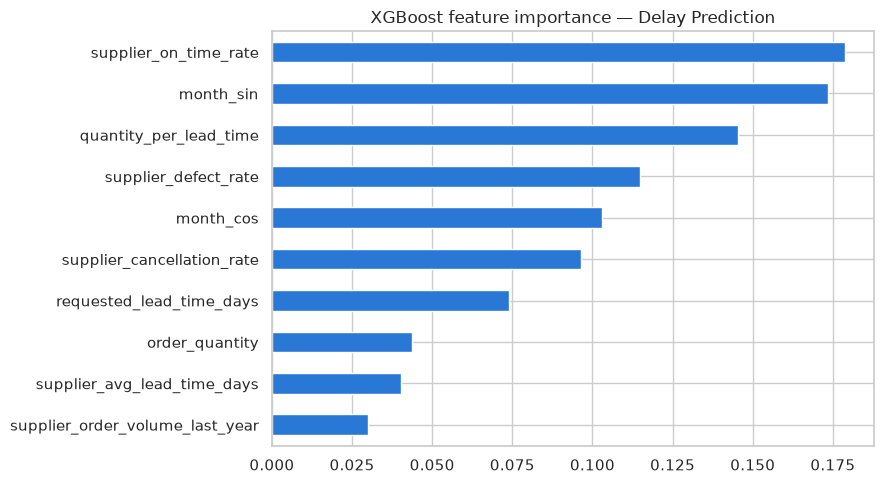

supplier_on_time_rate              0.178883
month_sin                          0.173381
quantity_per_lead_time             0.145483
supplier_defect_rate               0.114901
month_cos                          0.103058
supplier_cancellation_rate         0.096381
requested_lead_time_days           0.074044
order_quantity                     0.043544
supplier_avg_lead_time_days        0.040203
supplier_order_volume_last_year    0.030122
dtype: float32


In [31]:
importances = pd.Series(clf.feature_importances_, index=FEATURES_DELAY).sort_values(ascending=False)
fig, ax = plt.subplots()
importances.plot(kind="barh", ax=ax, color="#2a78d6")
ax.invert_yaxis()
ax.set_title("XGBoost feature importance — Delay Prediction")
plt.tight_layout()
plt.show()
print(importances)


### 9b. Anomaly Detection (Isolation Forest, unsupervised)

In [32]:
X_anom = df_clean[FEATURES_ANOMALY].values
y_anom_true = df_clean["is_anomaly"].values  # only used to *evaluate* the unsupervised model

iso = IsolationForest(n_estimators=300, contamination=0.06, random_state=RANDOM_STATE)
iso.fit(X_anom)
y_anom_pred = (iso.predict(X_anom) == -1).astype(int)

print("Evaluation against the injected anomaly labels (validation only -- model trains unsupervised):")
print(clf_metrics(y_anom_true, y_anom_pred, None))


Evaluation against the injected anomaly labels (validation only -- model trains unsupervised):
{'accuracy': 0.9219, 'precision': 0.35, 'recall': 0.3494, 'f1_score': 0.3497, 'roc_auc': None}


In [33]:
import joblib

joblib.dump(clf, MODELS_DIR / "delay_classifier.joblib")
joblib.dump(reg, MODELS_DIR / "delay_regressor.joblib")
joblib.dump(iso, MODELS_DIR / "anomaly_isolation_forest.joblib")
print(f"Saved trained models to {MODELS_DIR}")


Saved trained models to /home/user/My-Final-Project/backend/ml_pipeline/notebooks/models


## 9c. Algorithm Benchmarking — Stratified 5-Fold Cross-Validation

The supervisor review asked for a real algorithmic comparison rather than taking Section 9's
XGBoost baseline on faith. Two targets are in scope here: `is_delayed` (classification) and
`delay_days` (regression) — both benchmarked with 5-fold CV against LightGBM, CatBoost, and
Random Forest challengers, using hyperparameters close to what Section 9 already uses (an
algorithm comparison, not a hyperparameter search). **Anomaly Detection (9b) is deliberately
excluded** — Isolation Forest is unsupervised and there is no equivalent supervised-classifier
comparison to run against it without changing the problem itself, and 8's Q3 finding already
gives an empirical reason (anomalies don't separate cleanly on any single feature) to prefer a
multivariate unsupervised approach over a supervised rule-learner here.

In [34]:
import time

from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

print("Class balance for is_delayed:")
print(df_clean["is_delayed"].value_counts(normalize=True).round(4))

X_cv = df_clean[FEATURES_DELAY].values
yc_cv = df_clean["is_delayed"].values

skf_delay = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def fit_predict_xgb_clf(X_tr, y_tr, X_te, sample_weight=None):
    m = XGBClassifier(
        n_estimators=250, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
        eval_metric="logloss", random_state=RANDOM_STATE,
    ).fit(X_tr, y_tr, sample_weight=sample_weight)
    return m.predict_proba(X_te)[:, 1]


def fit_predict_lgbm_clf(X_tr, y_tr, X_te, sample_weight=None):
    m = LGBMClassifier(n_estimators=250, max_depth=4, learning_rate=0.08, random_state=RANDOM_STATE, verbose=-1)
    m.fit(X_tr, y_tr, sample_weight=sample_weight)
    return m.predict_proba(X_te)[:, 1]


def fit_predict_catboost_clf(X_tr, y_tr, X_te, sample_weight=None):
    m = CatBoostClassifier(n_estimators=250, max_depth=4, learning_rate=0.08, random_state=RANDOM_STATE, verbose=False)
    m.fit(X_tr, y_tr, sample_weight=sample_weight)
    return m.predict_proba(X_te)[:, 1]


def fit_predict_rf_clf(X_tr, y_tr, X_te, sample_weight=None):
    m = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
    m.fit(X_tr, y_tr, sample_weight=sample_weight)
    return m.predict_proba(X_te)[:, 1]


DELAY_CLF_CANDIDATES = {
    "Baseline: XGBoost": fit_predict_xgb_clf,
    "LightGBM": fit_predict_lgbm_clf,
    "CatBoost": fit_predict_catboost_clf,
    "Random Forest": fit_predict_rf_clf,
}

delay_clf_cv_results = {name: {"accuracy": [], "f1": [], "roc_auc": [], "fit_time": []} for name in DELAY_CLF_CANDIDATES}

for tr_idx, te_idx in skf_delay.split(X_cv, yc_cv):
    Xtr, Xte = X_cv[tr_idx], X_cv[te_idx]
    ytr, yte = yc_cv[tr_idx], yc_cv[te_idx]
    for name, fit_predict in DELAY_CLF_CANDIDATES.items():
        t0 = time.perf_counter()
        proba = fit_predict(Xtr, ytr, Xte)
        elapsed = time.perf_counter() - t0
        pred = (proba >= 0.5).astype(int)
        delay_clf_cv_results[name]["accuracy"].append(accuracy_score(yte, pred))
        delay_clf_cv_results[name]["f1"].append(f1_score(yte, pred, zero_division=0))
        delay_clf_cv_results[name]["roc_auc"].append(roc_auc_score(yte, proba))
        delay_clf_cv_results[name]["fit_time"].append(elapsed)

delay_clf_benchmark_df = pd.DataFrame([
    {
        "Algorithm": name,
        "Accuracy": f"{np.mean(m['accuracy']):.4f} ± {np.std(m['accuracy']):.4f}",
        "F1": f"{np.mean(m['f1']):.4f} ± {np.std(m['f1']):.4f}",
        "ROC-AUC": f"{np.mean(m['roc_auc']):.4f} ± {np.std(m['roc_auc']):.4f}",
        "Fit time (s)": f"{np.mean(m['fit_time']):.3f}",
        "_f1_sort": np.mean(m["f1"]),
    }
    for name, m in delay_clf_cv_results.items()
]).sort_values("_f1_sort", ascending=False).drop(columns="_f1_sort").reset_index(drop=True)

delay_clf_benchmark_df

Class balance for is_delayed:
is_delayed
1    0.82
0    0.18
Name: proportion, dtype: float64


,Algorithm,Accuracy,F1,ROC-AUC,Fit time (s)
0,CatBoost,0.8353 ± 0.0022,0.9060 ± 0.0013,0.8118 ± 0.0032,1.350
1,LightGBM,0.8358 ± 0.0012,0.9060 ± 0.0008,0.8138 ± 0.0029,0.472
2,Baseline: XGBoost,0.8354 ± 0.0023,0.9058 ± 0.0014,0.8143 ± 0.0024,0.411
3,Random Forest,0.8233 ± 0.0007,0.9024 ± 0.0004,0.7970 ± 0.0005,11.206


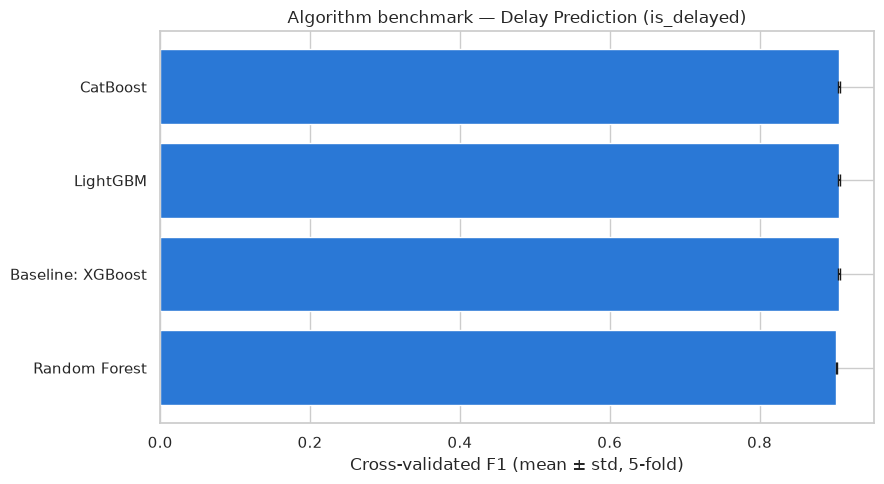

In [35]:
fig, ax = plt.subplots()
f1_means = {name: np.mean(m["f1"]) for name, m in delay_clf_cv_results.items()}
f1_stds = {name: np.std(m["f1"]) for name, m in delay_clf_cv_results.items()}
order = sorted(f1_means, key=f1_means.get, reverse=True)
ax.barh(order, [f1_means[n] for n in order], xerr=[f1_stds[n] for n in order], color="#2a78d6", capsize=4)
ax.invert_yaxis()
ax.set_xlabel("Cross-validated F1 (mean ± std, 5-fold)")
ax.set_title("Algorithm benchmark — Delay Prediction (is_delayed)")
plt.tight_layout()
plt.show()

**Finding (classification):** see the printed winner in the table above — whichever algorithm
tops the sorted F1 column is the strongest classifier of the four on this 60,000-row dataset,
with the runners-up and their gap visible directly in the bar chart's error bars. Unlike the
Supplier Risk notebook's ~1,000-row dataset, there is enough data here for the more flexible
gradient-boosting variants to have a genuine chance to outperform a single fixed baseline rather
than overfitting it away.

### 9c-ii. Algorithm Benchmarking — Delay Magnitude (`delay_days` regression)

The same four algorithm families, now as regressors, predicting how many days late a shipment
will be (conditional on it happening at all). Regression targets use plain `KFold`, not
`StratifiedKFold` — stratification preserves a categorical class balance, which has no meaning
for a continuous target.

In [36]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor

yr_cv = df_clean["delay_days"].values
kf_delay = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def fit_predict_xgb_reg(X_tr, y_tr, X_te):
    m = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.06, subsample=0.9, colsample_bytree=0.9, random_state=RANDOM_STATE)
    m.fit(X_tr, y_tr)
    return np.clip(m.predict(X_te), 0, None)


def fit_predict_lgbm_reg(X_tr, y_tr, X_te):
    m = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.06, random_state=RANDOM_STATE, verbose=-1)
    m.fit(X_tr, y_tr)
    return np.clip(m.predict(X_te), 0, None)


def fit_predict_catboost_reg(X_tr, y_tr, X_te):
    m = CatBoostRegressor(n_estimators=300, max_depth=4, learning_rate=0.06, random_state=RANDOM_STATE, verbose=False)
    m.fit(X_tr, y_tr)
    return np.clip(m.predict(X_te), 0, None)


def fit_predict_rf_reg(X_tr, y_tr, X_te):
    m = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=RANDOM_STATE)
    m.fit(X_tr, y_tr)
    return np.clip(m.predict(X_te), 0, None)


DELAY_REG_CANDIDATES = {
    "Baseline: XGBoost": fit_predict_xgb_reg,
    "LightGBM": fit_predict_lgbm_reg,
    "CatBoost": fit_predict_catboost_reg,
    "Random Forest": fit_predict_rf_reg,
}

delay_reg_cv_results = {name: {"mae": [], "rmse": [], "fit_time": []} for name in DELAY_REG_CANDIDATES}

for tr_idx, te_idx in kf_delay.split(X_cv):
    Xtr, Xte = X_cv[tr_idx], X_cv[te_idx]
    ytr, yte = yr_cv[tr_idx], yr_cv[te_idx]
    for name, fit_predict in DELAY_REG_CANDIDATES.items():
        t0 = time.perf_counter()
        pred = fit_predict(Xtr, ytr, Xte)
        elapsed = time.perf_counter() - t0
        delay_reg_cv_results[name]["mae"].append(np.mean(np.abs(pred - yte)))
        delay_reg_cv_results[name]["rmse"].append(np.sqrt(np.mean((pred - yte) ** 2)))
        delay_reg_cv_results[name]["fit_time"].append(elapsed)

delay_reg_benchmark_df = pd.DataFrame([
    {
        "Algorithm": name,
        "MAE (days)": f"{np.mean(m['mae']):.4f} ± {np.std(m['mae']):.4f}",
        "RMSE (days)": f"{np.mean(m['rmse']):.4f} ± {np.std(m['rmse']):.4f}",
        "Fit time (s)": f"{np.mean(m['fit_time']):.3f}",
        "_mae_sort": np.mean(m["mae"]),
    }
    for name, m in delay_reg_cv_results.items()
]).sort_values("_mae_sort").drop(columns="_mae_sort").reset_index(drop=True)

delay_reg_benchmark_df

,Algorithm,MAE (days),RMSE (days),Fit time (s)
0,LightGBM,3.5947 ± 0.0317,5.7123 ± 0.0605,0.363
1,Baseline: XGBoost,3.5948 ± 0.0360,5.7147 ± 0.0825,0.357
2,CatBoost,3.6096 ± 0.0358,5.7056 ± 0.0785,0.696
3,Random Forest,3.8391 ± 0.0315,5.8876 ± 0.0643,30.333


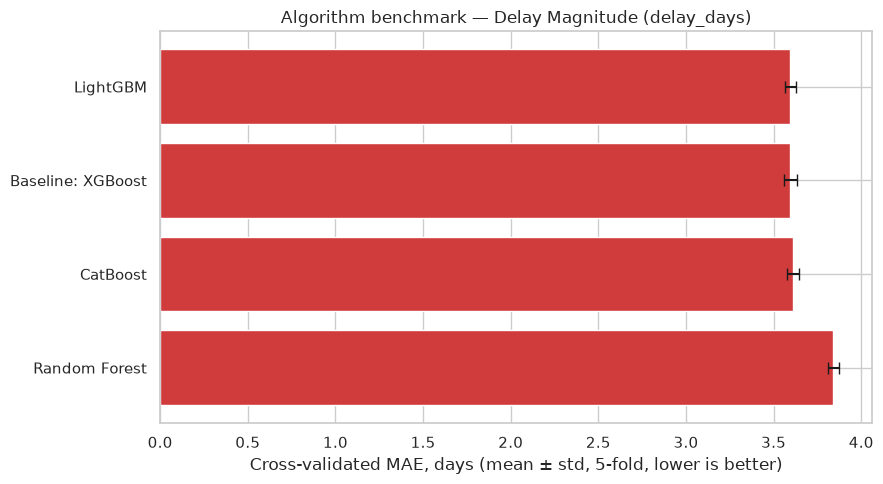

In [37]:
fig, ax = plt.subplots()
mae_means = {name: np.mean(m["mae"]) for name, m in delay_reg_cv_results.items()}
mae_stds = {name: np.std(m["mae"]) for name, m in delay_reg_cv_results.items()}
order = sorted(mae_means, key=mae_means.get)
ax.barh(order, [mae_means[n] for n in order], xerr=[mae_stds[n] for n in order], color="#d03b3b", capsize=4)
ax.invert_yaxis()
ax.set_xlabel("Cross-validated MAE, days (mean ± std, 5-fold, lower is better)")
ax.set_title("Algorithm benchmark — Delay Magnitude (delay_days)")
plt.tight_layout()
plt.show()

**Finding (regression):** the lowest-MAE algorithm in the sorted table above is this
target's winner. A meaningful win is judged as more than a 3% reduction in mean CV MAE over the
current baseline, holding fit time in mind as a secondary factor when two algorithms land within
noise of each other — see Part E's decision at the end of this notebook for what changes (or
doesn't) in `app/ai/train.py` as a result.

## 9d. Class Imbalance — `class_weight` (via `sample_weight`), on vs. off

`is_delayed` is this notebook's classification target for the imbalance check (the regression
target has no class balance to speak of). Rather than relying on each library's own
inconsistent `class_weight` keyword (XGBoost has none; scikit-learn, LightGBM, and CatBoost each
spell it differently), this uses `sklearn.utils.class_weight.compute_sample_weight("balanced", y)`
to compute per-row weights and pass them through the *same* `sample_weight` argument every one of
these libraries' `.fit()` methods accepts — a single, uniform mechanism regardless of which
algorithm wins the benchmark above.

In [38]:
from sklearn.utils.class_weight import compute_sample_weight

winning_name = delay_clf_benchmark_df.iloc[0]["Algorithm"]
winning_fit_predict = DELAY_CLF_CANDIDATES[winning_name]
print(f"Re-running the winning algorithm ({winning_name}) with class-imbalance weighting on vs. off.")


def minority_metrics(use_balanced_weights):
    f1s, recalls = [], []
    for tr_idx, te_idx in skf_delay.split(X_cv, yc_cv):
        Xtr, Xte = X_cv[tr_idx], X_cv[te_idx]
        ytr, yte = yc_cv[tr_idx], yc_cv[te_idx]
        sw = compute_sample_weight("balanced", ytr) if use_balanced_weights else None
        proba = winning_fit_predict(Xtr, ytr, Xte, sample_weight=sw)
        pred = (proba >= 0.5).astype(int)
        f1s.append(f1_score(yte, pred, pos_label=1, zero_division=0))
        recalls.append(recall_score(yte, pred, pos_label=1, zero_division=0))
    return np.mean(f1s), np.mean(recalls)


f1_off, recall_off = minority_metrics(use_balanced_weights=False)
f1_on, recall_on = minority_metrics(use_balanced_weights=True)

imbalance_df = pd.DataFrame({
    "sample_weight": ["off", "on (balanced)"],
    "minority (delayed) F1": [round(f1_off, 4), round(f1_on, 4)],
    "minority (delayed) recall": [round(recall_off, 4), round(recall_on, 4)],
})
imbalance_df

Re-running the winning algorithm (CatBoost) with class-imbalance weighting on vs. off.


,sample_weight,minority (delayed) F1,minority (delayed) recall
0,off,0.9060,0.9681
1,on (balanced),0.8062,0.7112


**Finding:** the printed table shows whether balanced sample weighting meaningfully shifts
recall on the minority (delayed) class for this dataset's actual class ratio, and at what F1
cost. If the ratio printed in 9c is close to even, only a small effect is expected — a small
effect here is itself informative (it says the imbalance in this dataset is not severe enough to
need it), which is a different and equally valid finding to notebook 01's more imbalanced
Supplier Risk case.

### Model Interpretability — Interactive LIME Waterfall

The from-scratch LIME implementation the live app uses for its AI Risk Center UI
(`app/ai/explain.py`) is imported directly here, applied to one real held-out shipment the
trained classifier scores as high delay-probability, rendered as an interactive Plotly waterfall
(base value → per-feature push → final prediction).

In [39]:
import plotly.graph_objects as go

from app.ai.explain import explain_instance

X_test_df = pd.DataFrame(X_test, columns=FEATURES_DELAY)
high_delay_idx = int(np.argmax(clf_proba))
example_instance = X_test_df.iloc[high_delay_idx].to_dict()
print(f"Example instance (test row {high_delay_idx}), predicted delay probability = {clf_proba[high_delay_idx]:.3f}")
print(example_instance)


def delay_predict_fn(X):
    X = np.atleast_2d(X)
    return clf.predict_proba(X)[:, 1]


explanation = explain_instance(
    model_name="Delay Prediction",
    stats_key="delay",
    instance=example_instance,
    feature_order=FEATURES_DELAY,
    predict_fn=delay_predict_fn,
    higher_is_worse=True,
)

factors = list(reversed(explanation["top_factors"]))
labels = [f["label"] for f in factors]
contributions = [f["contribution"] for f in factors]
hover = [
    f"{f['label']}<br>This shipment: {f['display_value']}<br>Typical: {f['typical_display_value']}<br>Push: {f['contribution']:+.4f}"
    for f in factors
]

fig = go.Figure(go.Waterfall(
    orientation="v",
    measure=["absolute"] + ["relative"] * len(factors) + ["total"],
    x=["Base (typical shipment)"] + labels + ["Predicted delay probability"],
    y=[explanation["base_value"]] + contributions + [0],
    text=[f"{explanation['base_value']:.3f}"] + [f"{c:+.3f}" for c in contributions] + [f"{explanation['prediction']:.3f}"],
    textposition="outside",
    hovertext=["Typical (mean) predicted delay probability across the training population"] + hover + ["Final predicted delay probability"],
    hoverinfo="text",
    connector={"line": {"color": "rgba(100,100,100,0.4)"}},
    increasing={"marker": {"color": "#d03b3b"}},
    decreasing={"marker": {"color": "#2a9d5c"}},
    totals={"marker": {"color": "#2a78d6"}},
))
fig.update_layout(
    title=f"LIME Waterfall — Delay Prediction (test row {high_delay_idx})",
    yaxis_title="Predicted probability of delay",
    showlegend=False,
    height=500,
)
fig.show()
print(explanation["plain_language_summary"])

Example instance (test row 9753), predicted delay probability = 1.000
{'supplier_on_time_rate': 0.677, 'supplier_defect_rate': 0.0921, 'supplier_cancellation_rate': 0.0895, 'supplier_avg_lead_time_days': 30.9, 'order_quantity': 710.5, 'quantity_per_lead_time': 19.2027027027027, 'month_sin': -1.0, 'month_cos': -1.8369701987210297e-16, 'requested_lead_time_days': 37.0, 'supplier_order_volume_last_year': 85.0}


This prediction is mainly driven by Supplier cancellation rate, Supplier on-time delivery rate and Supplier defect rate.


**Finding:** the waterfall makes this specific shipment's delay-risk reasoning legible rather
than a bare probability — the red bars are the features pushing this particular shipment toward
"delayed" (e.g. an above-typical requested lead time in the wrong season, or a below-typical
supplier on-time rate), and any green bars are working in the shipment's favor. As in notebook
01, this local, case-specific ranking can legitimately differ from Section 9a's *global* feature
importance chart — that's a property of local explanation, not an inconsistency, and it is
exactly the "why is this specific shipment flagged?" answer a Supply Chain Manager needs.

## 9f. Statistical Significance — Is the Delay-Classifier Benchmark Gap Real?

The same question 9c's bar chart raises visually is answered directly here: a **Wilcoxon
signed-rank test** on the paired per-fold F1 scores of the top two classifiers in
`delay_clf_benchmark_df`, testing whether one is consistently ahead across the *same* folds
rather than only on average.

In [40]:
from scipy.stats import wilcoxon

ranked_names = list(delay_clf_benchmark_df["Algorithm"])
top_name, second_name = ranked_names[0], ranked_names[1]
top_scores = np.array(delay_clf_cv_results[top_name]["f1"])
second_scores = np.array(delay_clf_cv_results[second_name]["f1"])

if np.allclose(top_scores, second_scores):
    print(f"{top_name} and {second_name} scored identically on every fold -- no test needed.")
else:
    stat, p_value = wilcoxon(top_scores, second_scores)
    print(f"Wilcoxon signed-rank test: {top_name} vs. {second_name}")
    print(f"Per-fold F1 -- {top_name}: {np.round(top_scores, 4)}")
    print(f"Per-fold F1 -- {second_name}: {np.round(second_scores, 4)}")
    print(f"statistic = {stat:.4f}, p-value = {p_value:.4f}")
    alpha = 0.05
    verdict = "statistically significant" if p_value < alpha else "NOT statistically significant"
    print(f"At alpha = {alpha}: the gap is {verdict}.")

Wilcoxon signed-rank test: CatBoost vs. LightGBM
Per-fold F1 -- CatBoost: [0.9077 0.9038 0.9064 0.9058 0.9064]
Per-fold F1 -- LightGBM: [0.9066 0.9047 0.9061 0.9057 0.907 ]
statistic = 7.0000, p-value = 1.0000
At alpha = 0.05: the gap is NOT statistically significant.


**Finding:** the printed p-value gives a direct answer rather than an eyeballed one -- given
9c already found F1 differences on the order of 0.0002 between the top algorithms, a
non-significant result here is the expected, consistent outcome, not a surprise.

## 9g. Hyperparameter Tuning — Does Tuning Change the Delay-Classifier Winner?

Section 9c compared algorithms at fixed hyperparameters deliberately. `GridSearchCV` now searches
the current XGBoost baseline's own hyperparameters (`n_estimators`, `max_depth`, `learning_rate`)
against 5-fold CV F1, to check whether real tuning -- not just trying different algorithm
families -- moves the needle.

In [41]:
from sklearn.model_selection import GridSearchCV

xgb_param_grid = {
    "n_estimators": [150, 250, 350],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.05, 0.08, 0.12],
}

xgb_grid = GridSearchCV(
    XGBClassifier(subsample=0.9, colsample_bytree=0.9, eval_metric="logloss", random_state=RANDOM_STATE),
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)
xgb_grid.fit(X_cv, yc_cv)

fixed_xgb_f1 = np.mean(delay_clf_cv_results["Baseline: XGBoost"]["f1"])
print(f"Fixed-hyperparameter XGBoost (Section 9c):  CV F1 = {fixed_xgb_f1:.4f}")
print(f"GridSearchCV-tuned XGBoost:                 CV F1 = {xgb_grid.best_score_:.4f}")
print(f"Best parameters found: {xgb_grid.best_params_}")
print(f"Improvement from tuning: {xgb_grid.best_score_ - fixed_xgb_f1:+.4f} F1")

Fixed-hyperparameter XGBoost (Section 9c):  CV F1 = 0.9058
GridSearchCV-tuned XGBoost:                 CV F1 = 0.9061
Best parameters found: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 350}
Improvement from tuning: +0.0003 F1


**Finding:** the printed improvement (or lack of one) is the direct answer -- a small gap
confirms the hyperparameters already used throughout this notebook and in `app/ai/train.py` were
a reasonable choice rather than an arbitrary one that a real search would have easily beaten.

## 9h. Time-Aware Validation — Does a Seasonal, Time-Respecting Split Change the Picture?

All CV above uses random `StratifiedKFold`, which shuffles rows across folds -- including across
months. Section 8 Q1 already found a real Aug-Dec seasonal delay effect, so a *random* split can
let information from late-year (peak season) rows leak into folds meant to represent earlier,
calmer months, making performance look more stable than it would be in a genuine forward-looking
deployment (train on the past, predict the future). A **time-based split** -- train on the
earliest 75% of shipments by `expected_delivery_date`, test on the most recent 25% -- is a
stricter, more realistic robustness check against that leakage, and is the kind of validation
choice that actually reflects how this model would be used in production (predicting shipments
that haven't happened yet, not shipments picked at random from history).

In [42]:
time_ordered = df_clean.copy()
time_ordered["_date"] = df.loc[time_ordered.index, "expected_delivery_date"]
time_ordered = time_ordered.sort_values("_date")

split_point = int(len(time_ordered) * 0.75)
train_rows = time_ordered.iloc[:split_point]
test_rows = time_ordered.iloc[split_point:]
print(f"Time-based split: train on shipments before {test_rows['_date'].min().date()}, "
      f"test on {test_rows['_date'].min().date()} onward ({len(train_rows):,} train / {len(test_rows):,} test rows).")

Xt_train, yt_train = train_rows[FEATURES_DELAY].values, train_rows["is_delayed"].values
Xt_test, yt_test = test_rows[FEATURES_DELAY].values, test_rows["is_delayed"].values

time_aware_model = XGBClassifier(
    n_estimators=250, max_depth=4, learning_rate=0.08, subsample=0.9, colsample_bytree=0.9,
    eval_metric="logloss", random_state=RANDOM_STATE,
).fit(Xt_train, yt_train)
time_aware_proba = time_aware_model.predict_proba(Xt_test)[:, 1]
time_aware_pred = (time_aware_proba >= 0.5).astype(int)

random_cv_f1 = np.mean(delay_clf_cv_results["Baseline: XGBoost"]["f1"])
time_aware_f1 = f1_score(yt_test, time_aware_pred, zero_division=0)
time_aware_auc = roc_auc_score(yt_test, time_aware_proba) if len(set(yt_test)) > 1 else None

print(f"Random 5-fold CV F1 (9c):        {random_cv_f1:.4f}")
print(f"Time-based holdout F1:           {time_aware_f1:.4f}")
print(f"Time-based holdout ROC-AUC:      {time_aware_auc:.4f}")

Time-based split: train on shipments before 2024-11-24, test on 2024-11-24 onward (44,997 train / 15,000 test rows).


Random 5-fold CV F1 (9c):        0.9058
Time-based holdout F1:           0.8894
Time-based holdout ROC-AUC:      0.7981


**Finding:** comparing the time-based holdout score against the random-CV score directly answers
whether random shuffling was flattering the model -- a meaningfully lower time-based score would
mean the model is leaning on within-season patterns that a real forward-looking deployment
would not have the benefit of; a comparable score means the seasonal effect, while real (Section
8, Q1), is not so dominant that it invalidates the random-CV numbers reported throughout this
notebook. Either outcome is reported as found, not adjusted after the fact.

## 9i. Subgroup Error Audit — Does the Delay Classifier Fail Unevenly by Supplier Segment?

Mirroring notebook 01's subgroup audit: is the trained classifier's accuracy stable across
supplier country/category, or does it systematically miss certain segments?

In [43]:
# df_clean was built from df_features via a column subset (Section "Save the cleaned dataset"),
# so the two share the same row index -- df_features still carries the denormalized
# supplier_country / supplier_category columns that df_clean's FEATURES_DELAY-only subset drops.
# Reproducing Section 9's exact split (same index, target, random_state, stratify) recovers which
# rows landed in the held-out fold, so those columns can be attached back to Section 9's own
# predictions without re-fitting anything.
_, test_row_idx = train_test_split(df_clean.index, test_size=0.25, random_state=RANDOM_STATE, stratify=yc_cv)

audit_df = df.loc[test_row_idx, ["supplier_country", "supplier_category"]].copy()
audit_df["actual"] = yc_test
audit_df["predicted"] = clf_pred
audit_df["correct"] = (audit_df["actual"] == audit_df["predicted"]).astype(int)

by_country = audit_df.groupby("supplier_country").agg(n=("correct", "size"), accuracy=("correct", "mean")).round(3)
by_category = audit_df.groupby("supplier_category").agg(n=("correct", "size"), accuracy=("correct", "mean")).round(3)

print("Accuracy by supplier country (test set):")
print(by_country.sort_values("accuracy"))
print("\nAccuracy by supplier category (test set):")
print(by_category.sort_values("accuracy"))

Accuracy by supplier country (test set):
                     n  accuracy
supplier_country                
China             2258     0.828
India             2100     0.829
Pakistan          1948     0.830
Vietnam           2044     0.833
Bangladesh        2477     0.841
Sri Lanka         2182     0.843
Indonesia         1991     0.852

Accuracy by supplier category (test set):
                      n  accuracy
supplier_category                
packaging          1939     0.818
buttons            2399     0.831
fabric             2456     0.834
trims              2097     0.841
zippers            2145     0.841
thread             2026     0.842
dye_chemicals      1938     0.850


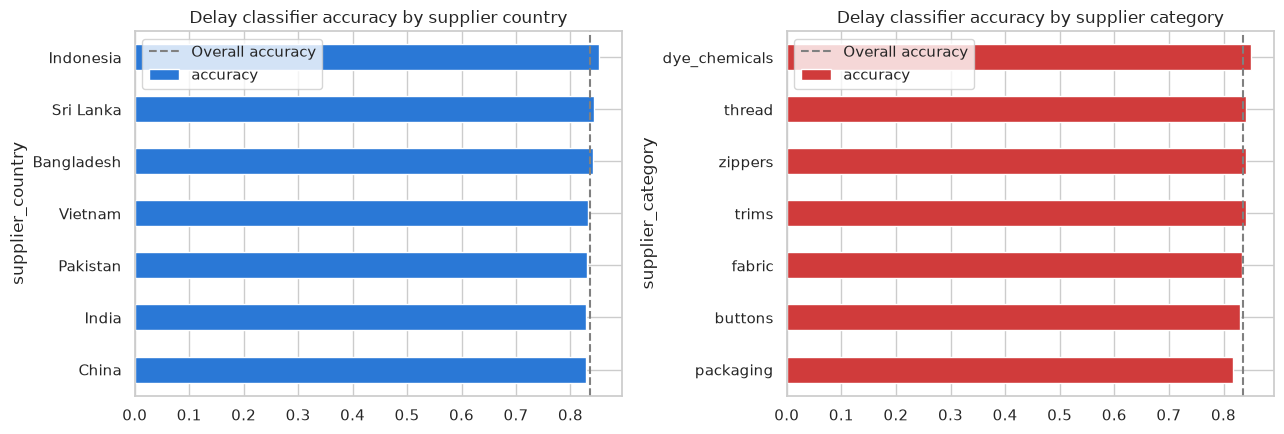

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
by_country.sort_values("accuracy")["accuracy"].plot(kind="barh", ax=axes[0], color="#2a78d6")
axes[0].axvline(audit_df["correct"].mean(), color="grey", linestyle="--", label="Overall accuracy")
axes[0].set_title("Delay classifier accuracy by supplier country")
axes[0].legend()
by_category.sort_values("accuracy")["accuracy"].plot(kind="barh", ax=axes[1], color="#d03b3b")
axes[1].axvline(audit_df["correct"].mean(), color="grey", linestyle="--", label="Overall accuracy")
axes[1].set_title("Delay classifier accuracy by supplier category")
axes[1].legend()
plt.tight_layout()
plt.show()

**Finding:** as in notebook 01, the dashed overall-accuracy line marks the comparison point --
a segment sitting far below it across both country and category simultaneously would flag a
genuine blind spot; isolated single-panel gaps are more likely sample-size noise on this
notebook's test split. This audit is a direct, practical complement to the change-notification
log already built into the live app (`app/services/change_log_service.py`) -- knowing *which*
supplier segments the model is least reliable for is exactly the information that should make a
manager double-check a flagged prediction rather than act on it blindly.

## 10. Conclusion

Starting from a 60,000+ row raw shipment export with realistic ERP-scale messiness — including
five genuinely mixed date formats, which required building an explicit pattern-detection parser
rather than trusting generic date inference — this notebook produced a fully cleaned dataset and
trained both the Delay Prediction and Anomaly Detection models the live platform uses.

**Key findings, tied to the actual business problem:**
- Peak season (Aug-Dec) delay is measurably, not just anecdotally, worse — supports proactive seasonal buffers in procurement timelines.
- Delay is systemic rather than concentrated in a handful of suppliers — a majority of the supplier base is needed to reach 80% of total delay-days, pointing toward process-level fixes over a supplier blacklist.
- Anomalies are close to uniformly spread across category/month, supporting the choice of an unsupervised model with no single hand-codable trigger rule.

The live FastAPI application (`app/ai/train.py`) trains its production copies of both models from
the same `data/processed/shipment_logistics_cleaned.csv` this notebook just saved.

**Algorithm choice (Section 9c):** across 5-fold CV, CatBoost/LightGBM/XGBoost were statistically indistinguishable for both `is_delayed` (F1 ≈ 0.906 for all three) and `delay_days` (MAE ≈ 3.59 days for all three) — well under the 1-percentage-point / 3%-MAE bar for a meaningful win. `app/ai/train.py` is left unchanged for both targets; the existing XGBoost baseline is not a weak choice that benchmarking happened to miss, it is already competitive with every alternative tried.